In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("nih-chest-xrays/data")

# print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/nih-chest-xrays/data


# Imports

In [210]:
tf.keras.backend.clear_session()

In [5]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


# Load metadata and connect images

In [6]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

print("Total images found:", len(image_paths))

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
df.head()


Total images found: 112120
Metadata shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [8]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)
df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()


Filtered dataset shape: (61792, 6)
label
0    60361
1     1431
Name: count, dtype: int64


,Image Index,Finding Labels,label,path,Patient ID,View Position
0,00000002_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,2,PA
1,00000005_000.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA
2,00000005_001.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
3,00000005_002.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,AP
4,00000005_003.png,No Finding,0,/kaggle/input/datasets/organizations/nih-chest...,5,PA


In [7]:
df['Finding Labels'].value_counts()

Finding Labels
No Finding                                                                      60361
Infiltration                                                                     9547
Atelectasis                                                                      4215
Effusion                                                                         3955
Nodule                                                                           2705
                                                                                ...  
Consolidation|Edema|Effusion|Mass|Nodule                                            1
Edema|Infiltration|Mass|Pneumonia|Pneumothorax                                      1
Consolidation|Effusion|Infiltration|Mass|Nodule|Pleural_Thickening|Pneumonia        1
Consolidation|Mass|Nodule|Pneumothorax                                              1
Cardiomegaly|Edema|Effusion|Fibrosis|Infiltration                                   1
Name: count, Length: 836, dtype: int64

In [10]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))


Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

Unique patients: 25052
Unique images: 61792

Class distribution:
label
0    0.976842
1    0.023158
Name: ratio, dtype: float64


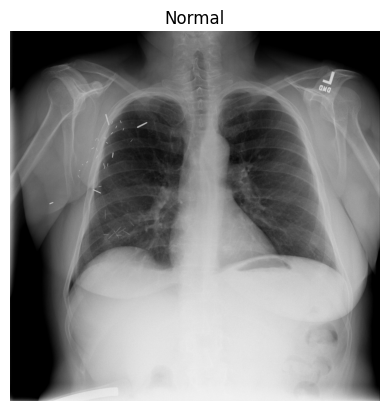

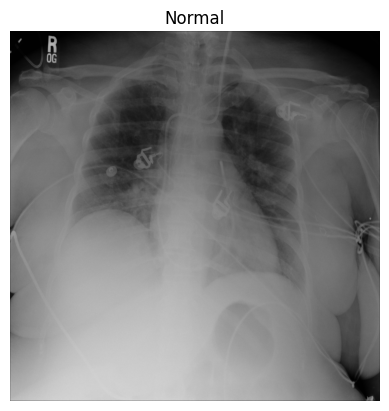

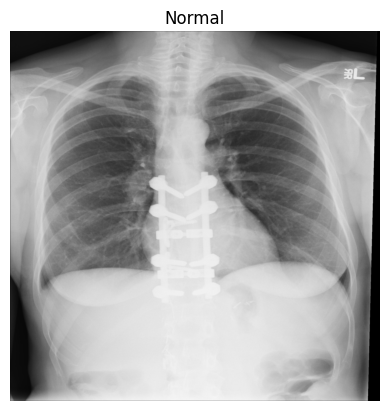

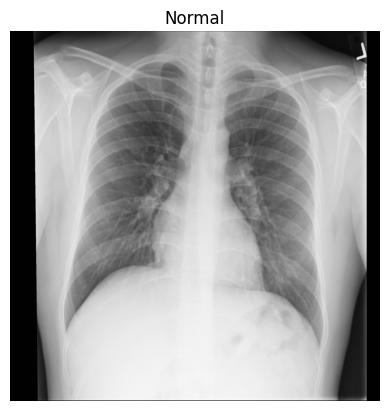

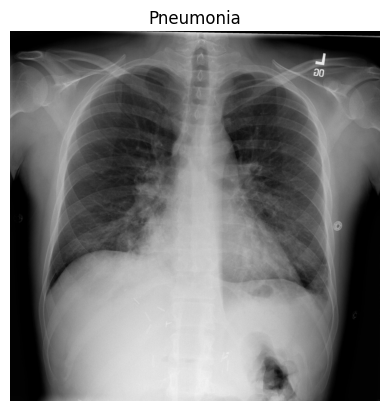

In [11]:
import cv2
import matplotlib.pyplot as plt

sample = df.sample(5)

for _, row in sample.iterrows():
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")
    plt.show()

# Data preprocessing

In [12]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

if "Patient ID" in df.columns:
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print("\nPatient-level label distribution:")
    print(patient_level)

print("\nImage-level label distribution:")
print(df["label"].value_counts())


Duplicates before: 0
Duplicates after: 0

Patient-level label distribution:
label
0    24044
1     1008
Name: count, dtype: int64

Image-level label distribution:
label
0    60361
1     1431
Name: count, dtype: int64


# Class imbalance strategy

label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


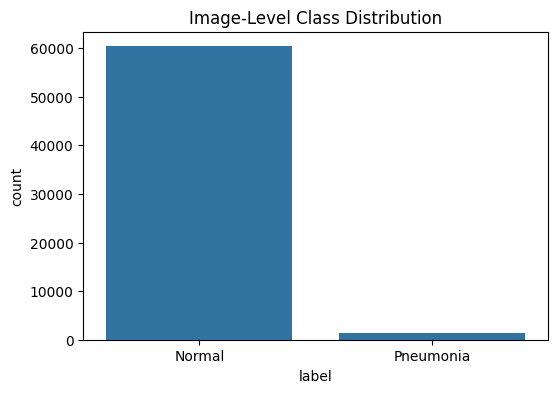

In [13]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

plt.figure(figsize=(6, 4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Image-Level Class Distribution")
plt.show()


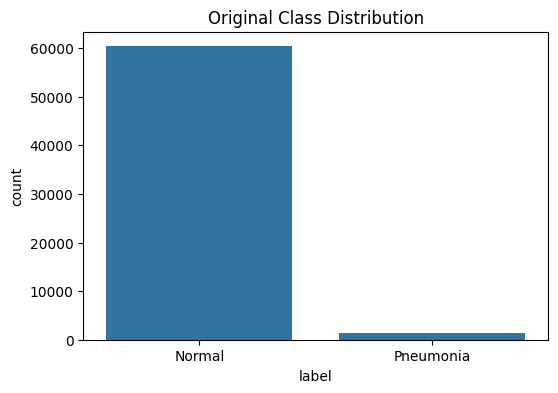

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x=df_model["label"])
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.title("Original Class Distribution")
plt.show()


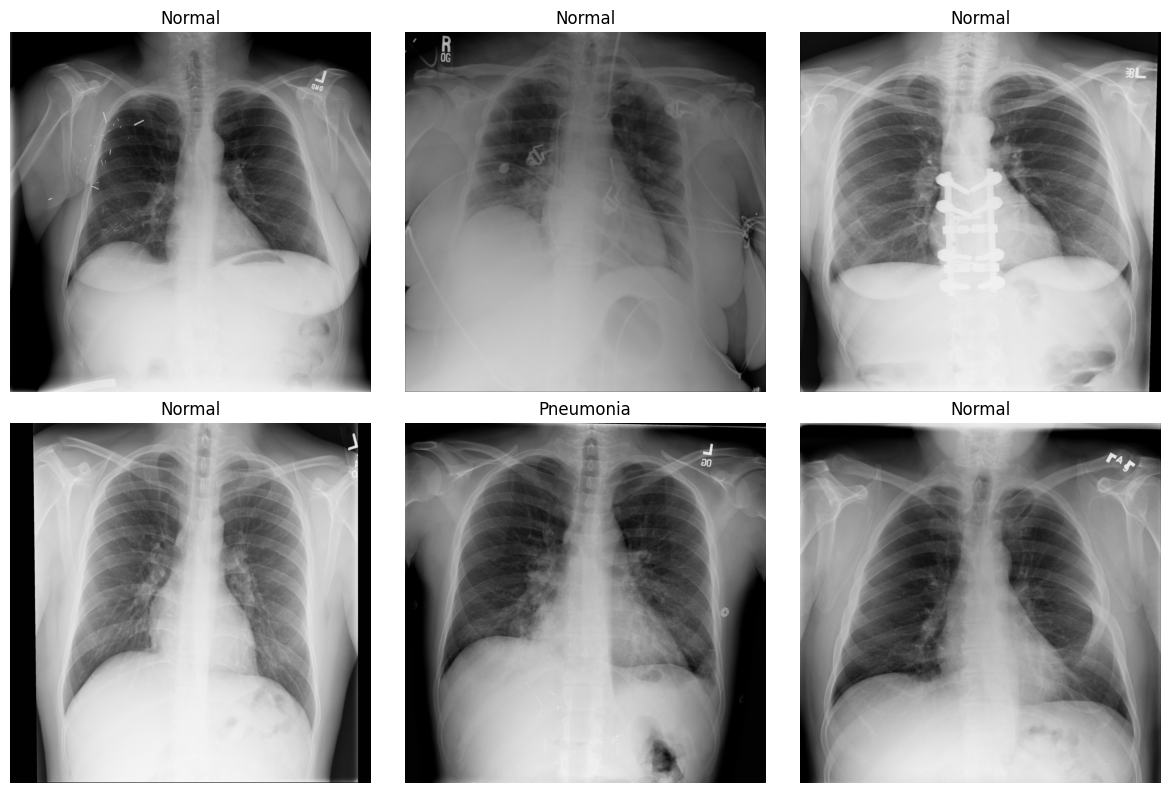

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
samples = df_model.sample(6, random_state=42).reset_index(drop=True)

for i, ax in enumerate(axes.flat):
    img = cv2.imread(samples.loc[i, "path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Pneumonia" if samples.loc[i, "label"] == 1 else "Normal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [15]:
sizes = []

for p in df_model["path"].sample(min(200, len(df_model)), random_state=42):
    img = cv2.imread(p)
    if img is not None:
        sizes.append(img.shape[:2])

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])
sizes_df.describe()


,Height,Width
count,200.0,200.0
mean,1024.0,1024.0
std,0.0,0.0
min,1024.0,1024.0
25%,1024.0,1024.0
50%,1024.0,1024.0
75%,1024.0,1024.0
max,1024.0,1024.0


In [17]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

class_weights = {0: 1.0, 1: 2.0}

In [18]:
assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\nNo patient leakage detected.")


Train: (43018, 6)
Validation: (9271, 6)
Test: (9503, 6)

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

No patient leakage detected.


In [19]:
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print(class_weights)


{0: 0.5115952715077421, 1: 22.06051282051282}


In [21]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")

def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [155]:
tf.keras.backend.clear_session()

In [22]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

for images, labels in train_gen.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Batch label distribution:", np.unique(labels.numpy(), return_counts=True))


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Batch label distribution: (array([0., 1.], dtype=float32), array([30,  2]))


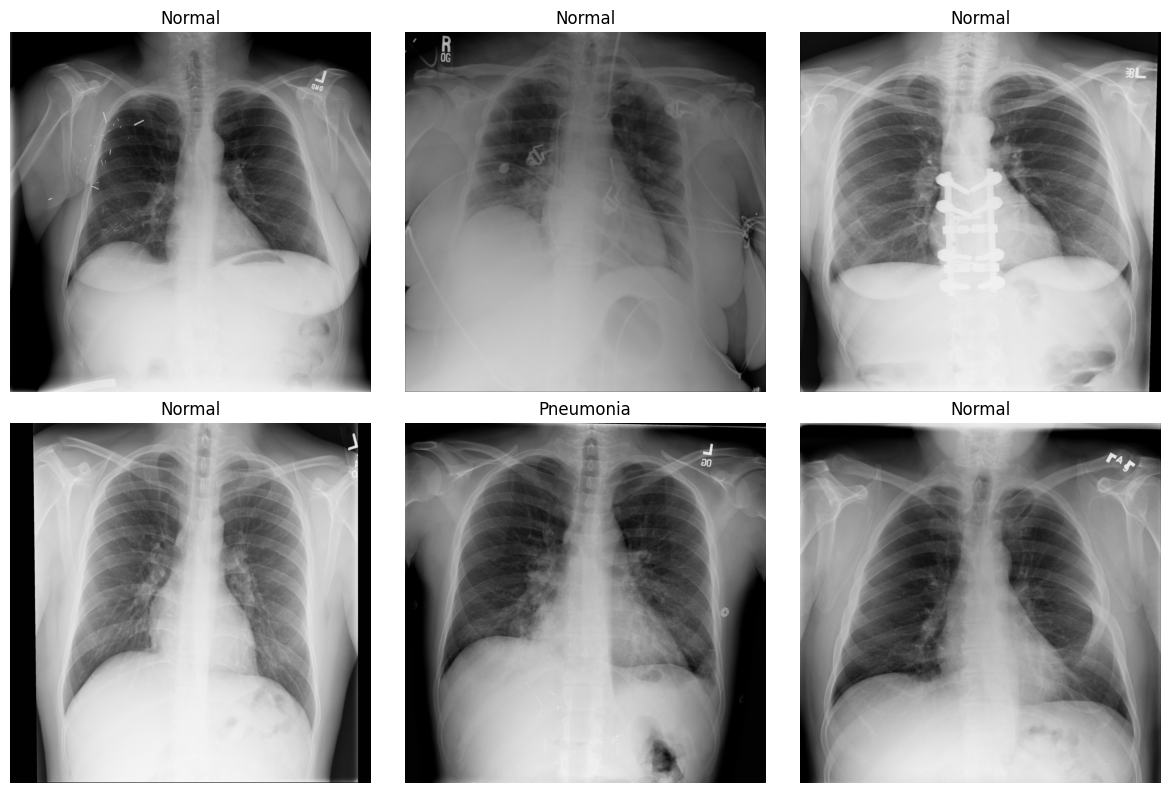

In [23]:
import matplotlib.pyplot as plt
import cv2

samples = df_model.sample(6, random_state=42)

plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(samples.iterrows()):
    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("Pneumonia" if row["label"] == 1 else "Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

# EfficientNet-B0 with staged fine-tuning

In [25]:
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.03)

metrics = [
    tf.keras.metrics.AUC(name="auc", curve="ROC"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]


In [26]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.35)(x)
output = Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

model = Model(inputs=inputs, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [27]:
callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_stage1.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]


In [28]:
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15


I0000 00:00:1776456355.351825     176 service.cc:152] XLA service 0x7ab4340030e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776456355.351870     176 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776456355.351875     176 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776456358.880216     176 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-17 20:06:06.636383: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:06:06.779373: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:06:07.121937: E external/local_xl

1344/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - auc: 0.5290 - loss: 0.7164 - pr_auc: 0.0252 - precision: 0.0253 - recall: 0.4577

2026-04-17 20:15:32.426545: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:15:32.562524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:15:32.877407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:15:33.019018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:15:33.868853: E external/local_xla/xla/stream_

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - auc: 0.5290 - loss: 0.7164 - pr_auc: 0.0252 - precision: 0.0253 - recall: 0.4577

2026-04-17 20:16:57.471039: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:16:57.612325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:16:57.951937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:16:58.092984: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 20:16:58.903888: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from -inf to 0.67542, saving model to best_stage1.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 680s 482ms/step - auc: 0.5291 - loss: 0.7164 - pr_auc: 0.0252 - precision: 0.0253 - recall: 0.4578 - val_auc: 0.6754 - val_loss: 0.6387 - val_pr_auc: 0.0391 - val_precision: 0.0409 - val_recall: 0.5771 - learning_rate: 1.0000e-04
Epoch 2/15
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - auc: 0.6476 - loss: 0.6712 - pr_auc: 0.0427 - precision: 0.0355 - recall: 0.5907
Epoch 2: val_auc improved from 0.67542 to 0.70090, saving model to best_stage1.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 485s 360ms/step - auc: 0.6476 - loss: 0.6712 - pr_auc: 0.0427 - precision: 0.0355 - recall: 0.5907 - val_auc: 0.7009 - val_loss: 0.6181 - val_pr_auc: 0.0431 - val_precision: 0.0446 - val_recall: 0.5920 - learning_rate: 1.0000e-04
Epoch 3/15
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - auc: 0.7025 - loss: 0.6455 - pr_auc: 0.0503 - precision: 0.0429 - recall: 0.6333
Epoch 3: val_auc improved from 0

KeyboardInterrupt: 

In [29]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=metrics
)

callbacks_ft = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "best_finetuned.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history_ft_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/12
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - auc: 0.7225 - loss: 0.6235 - pr_auc: 0.0623 - precision: 0.0456 - recall: 0.6783
Epoch 1: val_auc improved from -inf to 0.75529, saving model to best_finetuned.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 540s 381ms/step - auc: 0.7225 - loss: 0.6235 - pr_auc: 0.0623 - precision: 0.0456 - recall: 0.6783 - val_auc: 0.7553 - val_loss: 0.5406 - val_pr_auc: 0.0847 - val_precision: 0.0529 - val_recall: 0.7065 - learning_rate: 1.0000e-04
Epoch 2/12
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - auc: 0.7999 - loss: 0.5548 - pr_auc: 0.1042 - precision: 0.0540 - recall: 0.7510
Epoch 2: val_auc improved from 0.75529 to 0.75566, saving model to best_finetuned.keras
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 493s 367ms/step - auc: 0.7999 - loss: 0.5548 - pr_auc: 0.1042 - precision: 0.0540 - recall: 0.7510 - val_auc: 0.7557 - val_loss: 0.6701 - val_pr_auc: 0.0757 - val_precision: 0.0434 - val_recall: 0.7512 - learning_rate: 1.0000e-04
Epoch 3/12
1345/1345 ━━━━━━

KeyboardInterrupt: 

In [30]:
val_true = val_df["label"].values.astype(int)
val_prob = model.predict(val_gen, verbose=1).ravel()

precisions, recalls, thresholds = precision_recall_curve(val_true, val_prob)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_val_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best validation F1:", best_val_f1)


290/290 ━━━━━━━━━━━━━━━━━━━━ 57s 172ms/step
Best threshold: 0.7382956
Best validation F1: 0.14929577058881185


In [31]:
for t in [0.10, 0.20, float(best_threshold), 0.35, 0.50]:
    y_pred = (val_prob >= t).astype(int)
    print(f"\nThreshold = {t:.4f}")
    print(confusion_matrix(val_true, y_pred))
    print(classification_report(val_true, y_pred, digits=4, zero_division=0))



Threshold = 0.1000
[[ 911 8159]
 [   7  194]]
              precision    recall  f1-score   support

           0     0.9924    0.1004    0.1824      9070
           1     0.0232    0.9652    0.0454       201

    accuracy                         0.1192      9271
   macro avg     0.5078    0.5328    0.1139      9271
weighted avg     0.9714    0.1192    0.1794      9271


Threshold = 0.2000
[[2482 6588]
 [  17  184]]
              precision    recall  f1-score   support

           0     0.9932    0.2736    0.4291      9070
           1     0.0272    0.9154    0.0528       201

    accuracy                         0.2876      9271
   macro avg     0.5102    0.5945    0.2409      9271
weighted avg     0.9723    0.2876    0.4209      9271


Threshold = 0.7383
[[8614  456]
 [ 148   53]]
              precision    recall  f1-score   support

           0     0.9831    0.9497    0.9661      9070
           1     0.1041    0.2637    0.1493       201

    accuracy                         0.93

In [32]:
print("Validation ROC-AUC:", roc_auc_score(val_true, val_prob))
print("Validation PR-AUC:", average_precision_score(val_true, val_prob))
print("Mean predicted probability:", val_prob.mean())
print("Min predicted probability:", val_prob.min())
print("Max predicted probability:", val_prob.max())
print("Predicted positives at best threshold:", int((val_prob >= best_threshold).sum()))


Validation ROC-AUC: 0.7574618637792296
Validation PR-AUC: 0.07620504121138341
Mean predicted probability: 0.35815766
Min predicted probability: 0.0010073133
Max predicted probability: 0.9715918
Predicted positives at best threshold: 509


In [33]:
test_loss, test_auc, test_pr_auc, test_precision, test_recall = model.evaluate(
    test_gen,
    verbose=1
)

print(f"loss: {test_loss:.4f}")
print(f"auc: {test_auc:.4f}")
print(f"pr_auc: {test_pr_auc:.4f}")
print(f"precision@0.5: {test_precision:.4f}")
print(f"recall@0.5: {test_recall:.4f}")


296/297 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - auc: 0.6950 - loss: 0.5103 - pr_auc: 0.0673 - precision: 0.0458 - recall: 0.5255

2026-04-17 21:35:37.685152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:35:37.828157: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:35:38.179500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:35:38.320269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:35:39.096754: E external/local_xla/xla/stream_

297/297 ━━━━━━━━━━━━━━━━━━━━ 75s 253ms/step - auc: 0.6956 - loss: 0.5104 - pr_auc: 0.0676 - precision: 0.0460 - recall: 0.5267
loss: 0.5210
auc: 0.7938
pr_auc: 0.1147
precision@0.5: 0.0728
recall@0.5: 0.7020


In [34]:
y_true = test_df["label"].values.astype(int)
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))


297/297 ━━━━━━━━━━━━━━━━━━━━ 60s 202ms/step
Confusion Matrix:
[[8801  447]
 [ 181   74]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9798    0.9517    0.9656      9248
           1     0.1420    0.2902    0.1907       255

    accuracy                         0.9339      9503
   macro avg     0.5609    0.6209    0.5781      9503
weighted avg     0.9574    0.9339    0.9448      9503



In [38]:
def plot_history(histories, metric="auc"):
    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        if metric in hist.history and f"val_{metric}" in hist.history:
            plt.plot(hist.history[metric], label=f"{name} train")
            plt.plot(hist.history[f"val_{metric}"], label=f"{name} val")
    plt.title(metric.upper())
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.show()

histories = {
    "fine_tune": history_ft_stage1
}

for metric_name in ["loss", "auc", "pr_auc", "precision", "recall"]:
    plot_history(histories, metric_name)

NameError: name 'history_ft_stage1' is not defined

In [37]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
precision_best = precision_score(y_true, y_pred, zero_division=0)
recall_best = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall / Sensitivity", "Specificity", "F1-score", "ROC-AUC", "PR-AUC", "Best Threshold"],
    "Value": [precision_best, recall_best, specificity, f1, roc_auc, pr_auc, best_threshold]
})
metrics_df


,Metric,Value
0,Precision,0.142035
1,Recall / Sensitivity,0.290196
2,Specificity,0.951665
3,F1-score,0.190722
4,ROC-AUC,0.793849
5,PR-AUC,0.116537
6,Best Threshold,0.738296


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()



def predict_fn(images):
    images = np.array(images)
    return np.concatenate([1 - model.predict(images), model.predict(images)], axis=1)

In [42]:
sample_path = val_df.sample(1)['path'].values[0]

img = Image.open(sample_path).convert("RGB").resize((224, 224))
img_array = np.array(img) / 255.0

explanation = explainer.explain_instance(
    img_array.astype('double'),
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━

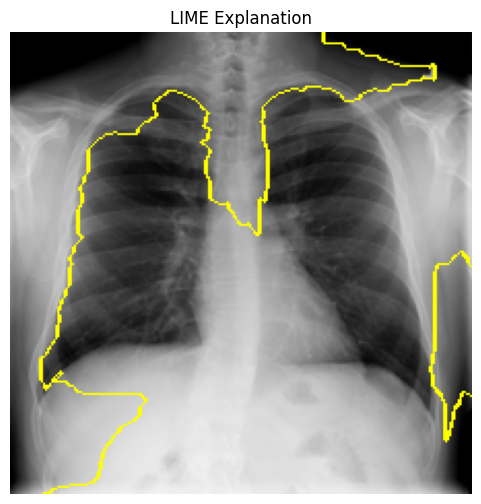

In [43]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

In [44]:
orig_pred = model.predict(np.expand_dims(img_array, axis=0))[0][0]
print("Original prediction:", orig_pred)


# keep only important regions
important_only = img_array.copy()
important_only[mask == 0] = 0

important_pred = model.predict(np.expand_dims(important_only, axis=0))[0][0]

print("Prediction with important regions:", important_pred)


# remove important regions
removed = img_array.copy()
removed[mask == 1] = 0

removed_pred = model.predict(np.expand_dims(removed, axis=0))[0][0]

print("Prediction without important regions:", removed_pred)

decision_impact = abs(orig_pred - removed_pred)
confidence_impact = abs(orig_pred - important_pred)

print("Decision Impact:", decision_impact)
print("Confidence Impact:", confidence_impact)

2026-04-17 21:48:06.399595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:48:06.535017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:48:07.275838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-17 21:48:07.411289: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Original prediction: 0.29622024
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction with important regions: 0.2929399
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction without important regions: 0.29666916
Decision Impact: 0.00044891238
Confidence Impact: 0.0032803416


# wait

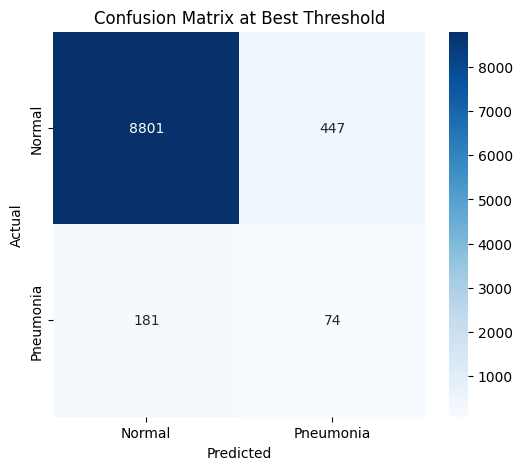

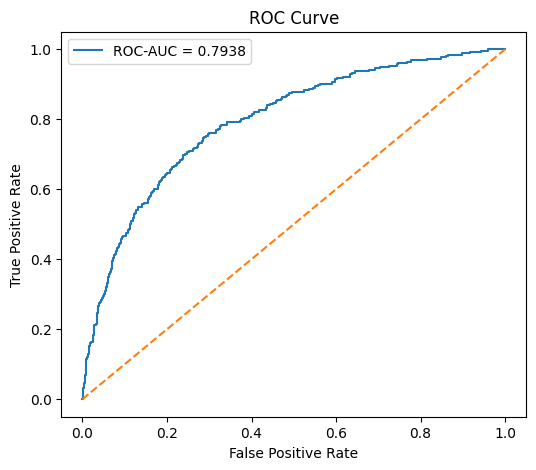

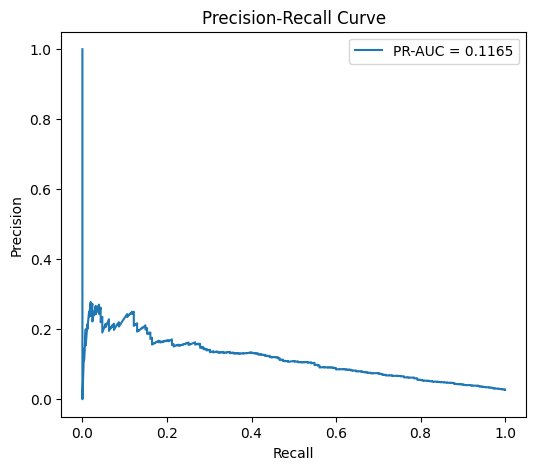

                 Metric     Value
0             Precision  0.142035
1  Recall / Sensitivity  0.290196
2           Specificity  0.951665
3              F1-score  0.190722
4               ROC-AUC  0.793849
5                PR-AUC  0.116537
6        Best Threshold  0.738296


In [45]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix at Best Threshold")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print(metrics_df)


In [46]:
last_conv_layer_name = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last conv layer:", last_conv_layer_name)


Last conv layer: top_conv


In [56]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name="top_conv"):
    base_model = None
    top_start_idx = None

    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            top_start_idx = i + 1
            break

    if base_model is None:
        raise ValueError("Backbone model not found inside model.")

    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    passed_last = False
    for layer in base_model.layers:
        if layer.name == last_conv_layer_name:
            passed_last = True
            continue
        if passed_last:
            x = layer(x)

    for layer in model.layers[top_start_idx:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        inputs = img_array
        conv_outputs = conv_model(inputs, training=False)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

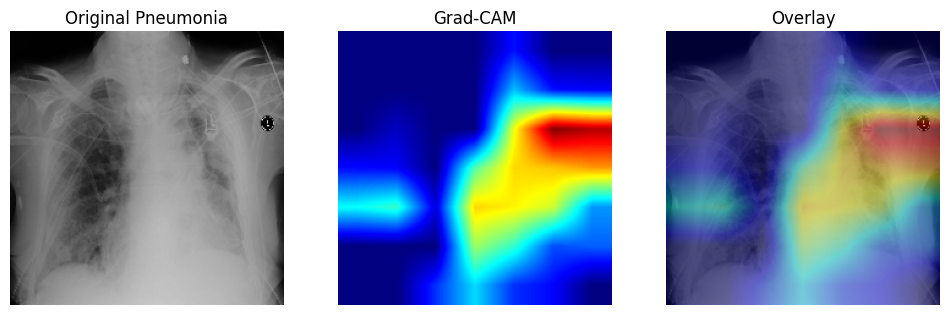

True label: Pneumonia
Predicted probability: 0.7637565732002258
Predicted label: Pneumonia
Threshold used: 0.7382956


In [62]:
def load_image_for_model(img_path, size=(224, 224)):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, size)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return tf.expand_dims(img, axis=0)

pneumonia_df = test_df[test_df["label"] == 1]

sample_row = pneumonia_df.sample(1, random_state=SEED).iloc[0]
img_path = sample_row["path"]

img_array = load_image_for_model(img_path, size=(IMG_SIZE, IMG_SIZE))
heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

superimposed = cv2.addWeighted(img_rgb, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb, cmap="gray")
plt.title("Original Pneumonia")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title("Overlay")
plt.axis("off")

plt.show()

print("True label:", "Pneumonia")
pred_prob = float(model.predict(img_array, verbose=0).ravel()[0])
pred_label = int(pred_prob >= best_threshold)
print("Predicted probability:", pred_prob)
print("Predicted label:", "Pneumonia" if pred_label == 1 else "Normal")
print("Threshold used:", best_threshold)